# Codveda Task 3 : Linear Regression Model for Stocks

## Importing libraries and load the dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
# Loading dataset

df = pd.read_csv(r"E:\Codveda projects\datasets\2) Stock Prices Data Set.csv")

## Inspecting and cleaning the dataset

In [4]:
# head 5
df.head(5)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [5]:
# tail 5
df.tail(5)

,symbol,date,open,high,low,close,volume
497467,XYL,2017-12-29,68.53,68.80,67.92,68.20,1046677
497468,YUM,2017-12-29,82.64,82.71,81.59,81.61,1347613
497469,ZBH,2017-12-29,121.75,121.95,120.62,120.67,1023624
497470,ZION,2017-12-29,51.28,51.55,50.81,50.83,1261916
497471,ZTS,2017-12-29,72.55,72.76,72.04,72.04,1704122


In [6]:
# sample 20
df.sample(10)

,symbol,date,open,high,low,close,volume
47630,IFF,2014-05-23,98.00,98.9200,97.8001,98.86,157746
141426,UNP,2015-02-27,121.15,121.4000,120.1900,120.26,2775550
283349,ALGN,2016-04-21,73.73,74.1960,73.0400,73.30,440813
184498,AGN,2015-07-07,307.58,308.7500,301.8700,307.00,1707162
140356,PG,2015-02-25,85.70,85.7950,85.2399,85.46,5975834
6271,XOM,2014-01-21,98.57,98.8856,98.0400,98.50,13848381
50950,EQIX,2014-06-04,196.00,200.0000,196.0000,199.82,657323
450556,VLO,2017-08-17,65.67,65.7100,64.4700,64.55,3358377
253301,IP,2016-01-25,34.98,35.0100,32.5000,32.58,14645182
168914,CHRW,2015-05-20,64.83,64.9160,63.8600,63.91,904698


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [8]:
# Detect null values and checking them

df.isna().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [9]:
# Clean nulls by removing

df.dropna(inplace=True)

In [10]:
df.isna().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [11]:
# summary statistics

df.describe()

,open,high,low,close,volume
count,497461.000000,497461.000000,497461.000000,497461.000000,4.974610e+05
mean,86.352275,87.132717,85.552616,86.368586,4.253695e+06
std,101.471228,102.312340,100.571231,101.471516,8.232210e+06
min,1.620000,1.690000,1.500000,1.590000,1.010000e+02
25%,41.690000,42.090000,41.280000,41.700000,1.080183e+06
50%,64.970000,65.560000,64.357400,64.980000,2.085013e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271999e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [12]:
# data structure

df.shape

(497461, 7)

## Task 3: Linear Regression Model

In [13]:
# First select the variables for the model
X = df[["open"]] # must be 2D (independent variable)
y = df["close"] # dependent variable

In [14]:
# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Linear Regression Model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Predict close prices for test data
y_pred = model.predict(X_test)

In [17]:
# R -squared 
r2 = r2_score(y_test, y_pred)

# Mean Square Error
mse = mean_squared_error(y_test, y_pred)

print("R-squared:", r2)  # Print R-squared value
print("Mean Squared Error:", mse)  # Print MSE value

R-squared: 0.9997383343436389
Mean Squared Error: 2.726082368531974


In [18]:
coefficient = model.coef_[0]  # Extract slope coefficient
intercept = model.intercept_  # Extract intercept

print("Coefficient (Slope):", coefficient)  
print("Intercept:", intercept)

Coefficient (Slope): 0.999874498139709
Intercept: 0.026677540332286753


Model Visualization

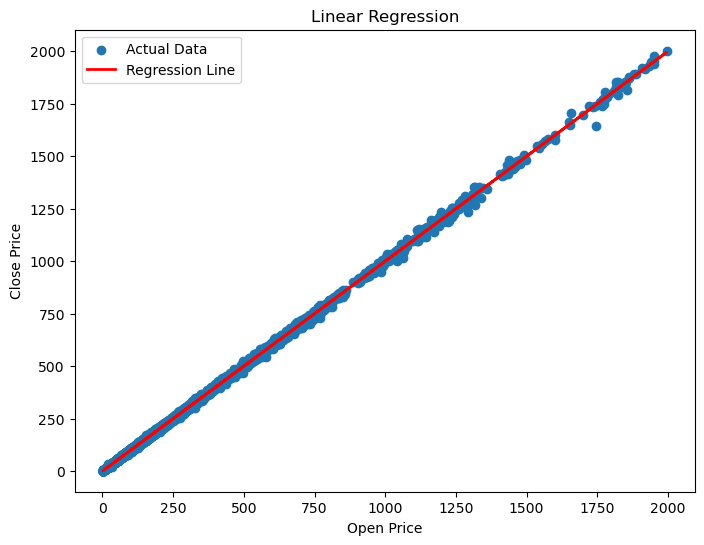

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Linear Regression")
plt.legend()
plt.show()

Model Evaluation

In [22]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.7691860843468409
RMSE: 1.6510852093492856
R²: 0.9997383343436389


Testing Model with new data

In [25]:
new_data = [
    [120.321],
    [130.234],
    [140.122],
    [150.903]
]

test_pred = model.predict(new_data)
print(test_pred)

[120.33257703 130.24433293 140.13109197 150.91073893]


e:\Conda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Saving Model

In [26]:
import joblib

joblib.dump(model, "linear_regression_stock_model.pkl")

['linear_regression_stock_model.pkl']

You can use the model by following steps.
* *import joblib*
* *model = joblib.load("linear_regression_stock_model.pkl")*